<a href="https://www.kaggle.com/code/sonawanelalitsunil/startup-growth-funding-insights-knn-56?scriptVersionId=227507500" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/startup-growth-and-funding-trends/startup_data.csv


## Title : Startup Growth & Funding Insights

## Description:
Analyze key trends in startup growth, funding rounds, valuations, and profitability. Explore industry-wise funding patterns, market share distribution, and the impact of investment on revenue and exit success.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/startup-growth-and-funding-trends/startup_data.csv')

In [3]:
df.head()

,Startup Name,Industry,Funding Rounds,Funding Amount (M USD),Valuation (M USD),Revenue (M USD),Employees,Market Share (%),Profitable,Year Founded,Region,Exit Status
0,Startup_1,IoT,1,101.09,844.75,67.87,1468,5.20,0,2006,Europe,Private
1,Startup_2,EdTech,1,247.62,3310.83,75.65,3280,8.10,1,2003,South America,Private
2,Startup_3,EdTech,1,109.24,1059.37,84.21,4933,2.61,1,1995,South America,Private
3,Startup_4,Gaming,5,10.75,101.90,47.08,1059,2.53,0,2003,South America,Private
4,Startup_5,IoT,4,249.28,850.11,50.25,1905,4.09,0,1997,Europe,Acquired


In [4]:
df.tail()

,Startup Name,Industry,Funding Rounds,Funding Amount (M USD),Valuation (M USD),Revenue (M USD),Employees,Market Share (%),Profitable,Year Founded,Region,Exit Status
495,Startup_496,EdTech,2,181.86,2378.65,59.64,3331,0.58,1,1993,Europe,Private
496,Startup_497,AI,2,107.34,1394.58,10.22,2223,5.85,0,2019,South America,Private
497,Startup_498,E-Commerce,1,160.29,502.09,84.73,2222,4.32,0,2019,Australia,Private
498,Startup_499,Gaming,5,234.65,2814.52,53.16,4972,5.53,0,2011,Europe,Private
499,Startup_500,HealthTech,4,211.76,2563.17,84.19,2374,5.26,0,2000,North America,Private


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Startup Name            500 non-null    object 
 1   Industry                500 non-null    object 
 2   Funding Rounds          500 non-null    int64  
 3   Funding Amount (M USD)  500 non-null    float64
 4   Valuation (M USD)       500 non-null    float64
 5   Revenue (M USD)         500 non-null    float64
 6   Employees               500 non-null    int64  
 7   Market Share (%)        500 non-null    float64
 8   Profitable              500 non-null    int64  
 9   Year Founded            500 non-null    int64  
 10  Region                  500 non-null    object 
 11  Exit Status             500 non-null    object 
dtypes: float64(4), int64(4), object(4)
memory usage: 47.0+ KB


In [6]:
df.describe()

,Funding Rounds,Funding Amount (M USD),Valuation (M USD),Revenue (M USD),Employees,Market Share (%),Profitable,Year Founded
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2.958000,152.656760,1371.809180,49.321740,2532.092000,5.092940,0.432000,2006.044000
std,1.440968,86.683711,978.226579,29.267605,1385.434921,2.807646,0.495851,9.347128
min,1.000000,0.570000,2.430000,0.120000,12.000000,0.100000,0.000000,1990.000000
25%,2.000000,79.212500,557.027500,22.802500,1382.750000,2.760000,0.000000,1998.000000
50%,3.000000,156.005000,1222.580000,48.800000,2496.500000,5.135000,0.000000,2006.000000
75%,4.000000,226.450000,2052.085000,74.965000,3708.750000,7.552500,1.000000,2014.000000
max,5.000000,299.810000,4357.490000,99.710000,4984.000000,10.000000,1.000000,2022.000000


In [7]:
df.isnull().sum()

Startup Name              0
Industry                  0
Funding Rounds            0
Funding Amount (M USD)    0
Valuation (M USD)         0
Revenue (M USD)           0
Employees                 0
Market Share (%)          0
Profitable                0
Year Founded              0
Region                    0
Exit Status               0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

Startup Name               object
Industry                   object
Funding Rounds              int64
Funding Amount (M USD)    float64
Valuation (M USD)         float64
Revenue (M USD)           float64
Employees                   int64
Market Share (%)          float64
Profitable                  int64
Year Founded                int64
Region                     object
Exit Status                object
dtype: object

In [10]:
df.corr

<bound method DataFrame.corr of     Startup Name    Industry  Funding Rounds  Funding Amount (M USD)  \
0      Startup_1         IoT               1                  101.09   
1      Startup_2      EdTech               1                  247.62   
2      Startup_3      EdTech               1                  109.24   
3      Startup_4      Gaming               5                   10.75   
4      Startup_5         IoT               4                  249.28   
..           ...         ...             ...                     ...   
495  Startup_496      EdTech               2                  181.86   
496  Startup_497          AI               2                  107.34   
497  Startup_498  E-Commerce               1                  160.29   
498  Startup_499      Gaming               5                  234.65   
499  Startup_500  HealthTech               4                  211.76   

     Valuation (M USD)  Revenue (M USD)  Employees  Market Share (%)  \
0               844.75         

In [11]:
df.shape

(500, 12)

In [12]:
df.columns

Index(['Startup Name', 'Industry', 'Funding Rounds', 'Funding Amount (M USD)',
       'Valuation (M USD)', 'Revenue (M USD)', 'Employees', 'Market Share (%)',
       'Profitable', 'Year Founded', 'Region', 'Exit Status'],
      dtype='object')

## Data visualizations

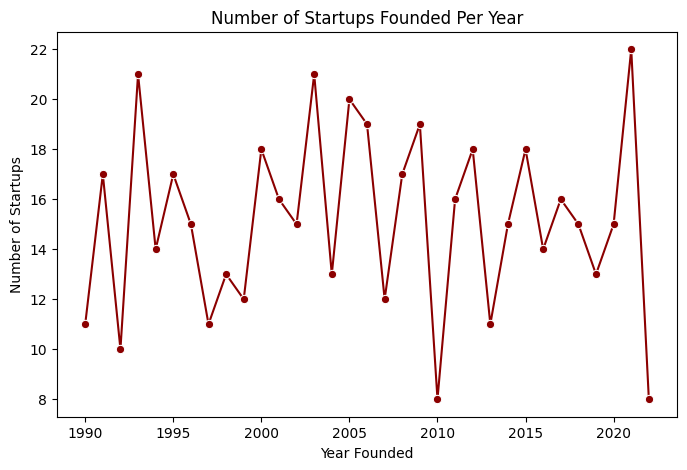

In [13]:
plt.figure(figsize=(8, 5))
startup_counts_per_year = df['Year Founded'].value_counts().sort_index()
sns.lineplot(x=startup_counts_per_year.index, y=startup_counts_per_year.values, marker='o', color='darkred')
plt.title('Number of Startups Founded Per Year')
plt.xlabel('Year Founded')
plt.ylabel('Number of Startups')
plt.show()

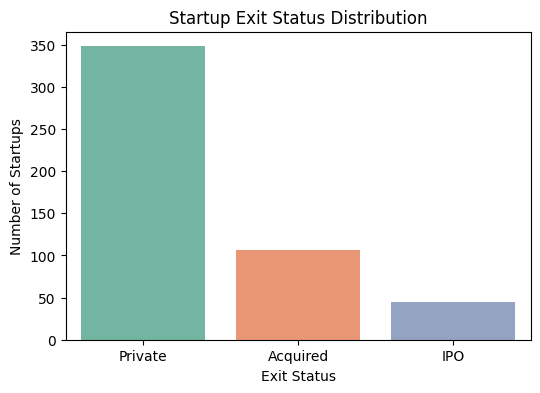

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df['Exit Status'], palette='Set2')
plt.title('Startup Exit Status Distribution')
plt.xlabel('Exit Status')
plt.ylabel('Number of Startups')
plt.show()

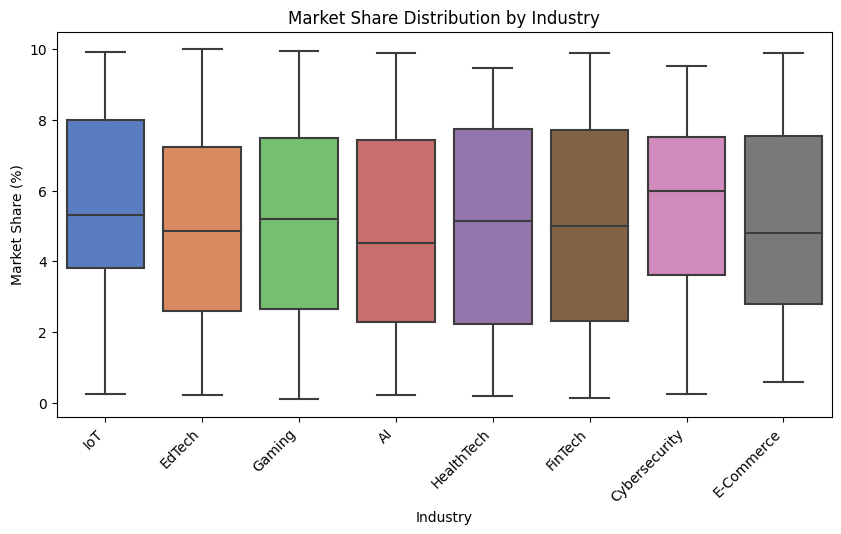

In [15]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Industry'], y=df['Market Share (%)'], palette='muted')
plt.xticks(rotation=45, ha='right')
plt.title('Market Share Distribution by Industry')
plt.xlabel('Industry')
plt.ylabel('Market Share (%)')
plt.show()

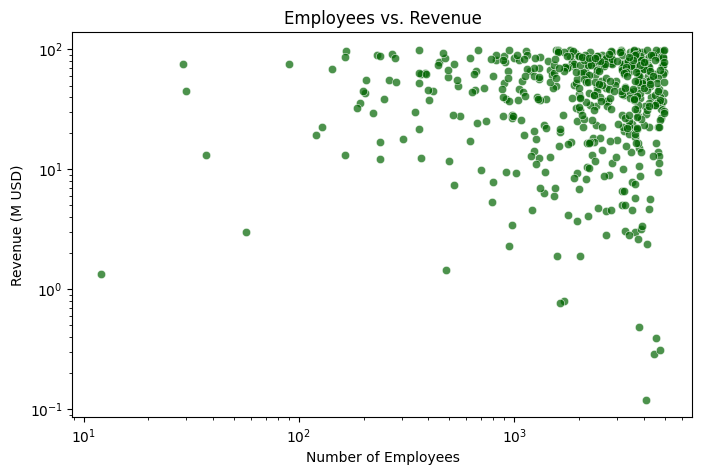

In [16]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['Employees'], y=df['Revenue (M USD)'], alpha=0.7, color='darkgreen')
plt.title('Employees vs. Revenue')
plt.xlabel('Number of Employees')
plt.ylabel('Revenue (M USD)')
plt.xscale('log')  # Log scale for better visibility
plt.yscale('log')
plt.show()

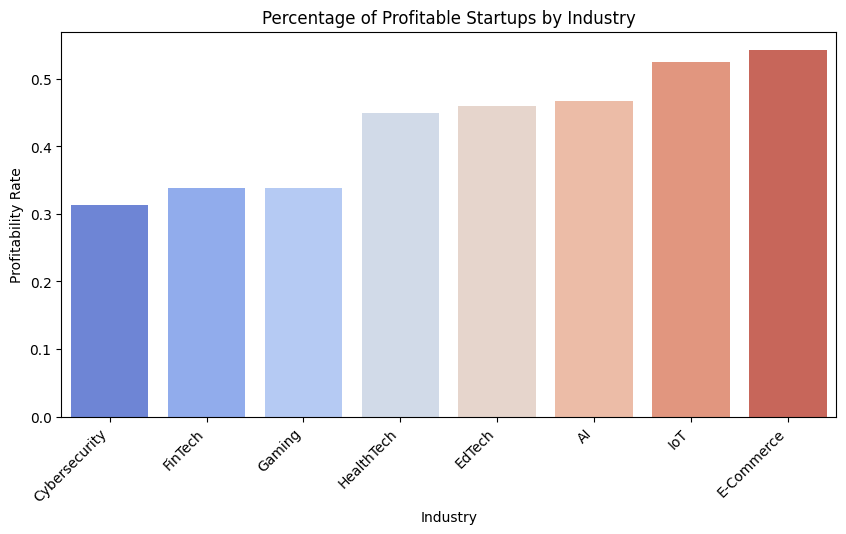

In [17]:
plt.figure(figsize=(10, 5))
profit_counts = df.groupby('Industry')['Profitable'].mean().sort_values()
sns.barplot(x=profit_counts.index, y=profit_counts.values, palette='coolwarm')
plt.xticks(rotation=45, ha='right')
plt.title('Percentage of Profitable Startups by Industry')
plt.xlabel('Industry')
plt.ylabel('Profitability Rate')
plt.show()

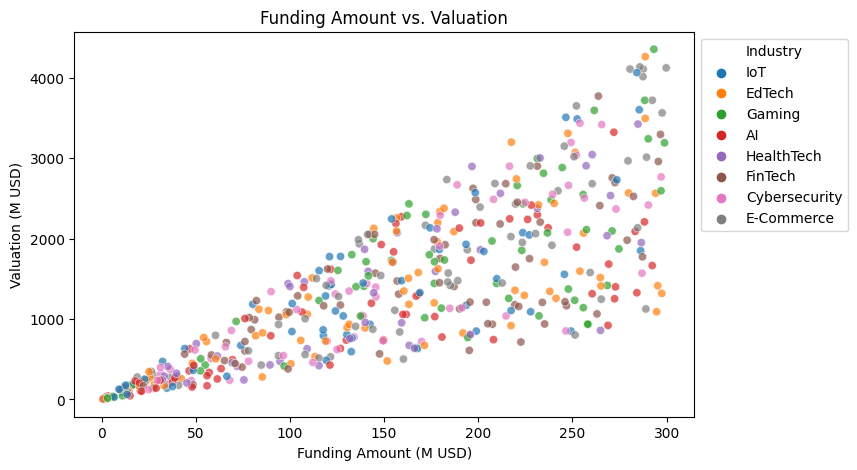

In [18]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['Funding Amount (M USD)'], y=df['Valuation (M USD)'], hue=df['Industry'], alpha=0.7)
plt.title('Funding Amount vs. Valuation')
plt.xlabel('Funding Amount (M USD)')
plt.ylabel('Valuation (M USD)')
plt.legend(title='Industry', bbox_to_anchor=(1, 1))
plt.show()

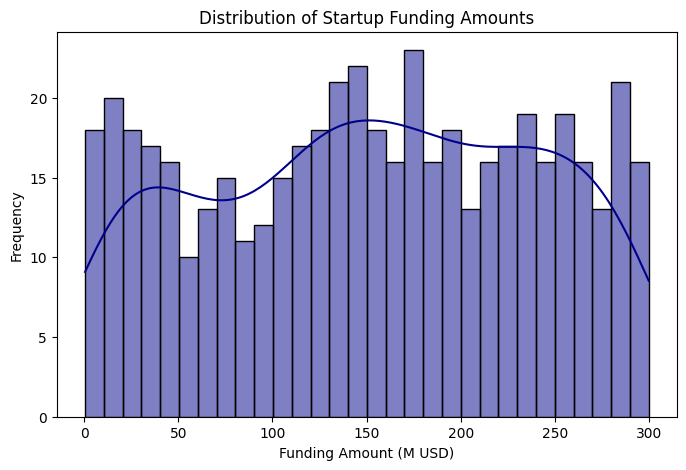

In [19]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Funding Amount (M USD)'], bins=30, kde=True, color='darkblue')
plt.title('Distribution of Startup Funding Amounts')
plt.xlabel('Funding Amount (M USD)')
plt.ylabel('Frequency')
plt.show()

## Predictive modeling

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error

In [21]:
target_column = 'Profitable'

# 🔹 Label Encoding for Categorical Columns
label_encoders = {}
categorical_cols = ['Industry', 'Region', 'Exit Status']


In [22]:
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


In [23]:
X = df.drop(columns=[target_column, 'Startup Name'])  # Remove target & non-useful column
y = df[target_column]  # Classification: 0 or 1

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
models = {
    'RandomForest': RandomForestClassifier() if y.nunique() == 2 else RandomForestRegressor(),
    'LogisticRegression': LogisticRegression() if y.nunique() == 2 else LinearRegression(),
    'DecisionTree': DecisionTreeClassifier() if y.nunique() == 2 else DecisionTreeRegressor(),
    'SVM': SVC() if y.nunique() == 2 else SVR(),
    'KNN': KNeighborsClassifier() if y.nunique() == 2 else KNeighborsRegressor()
}

In [27]:
# 🔹 Train & Evaluate Models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if y.nunique() == 2:  # Classification Metrics
        acc = accuracy_score(y_test, y_pred)
        print(f"{name} Accuracy: {acc:.4f}")
    else:  # Regression Metrics
        r2 = r2_score(y_test, y_pred)
        rmse = mean_squared_error(y_test, y_pred, squared=False)
        print(f"{name} R² Score: {r2:.4f}, RMSE: {rmse:.4f}")

RandomForest Accuracy: 0.5300
LogisticRegression Accuracy: 0.4900
DecisionTree Accuracy: 0.5100
SVM Accuracy: 0.5100
KNN Accuracy: 0.5600


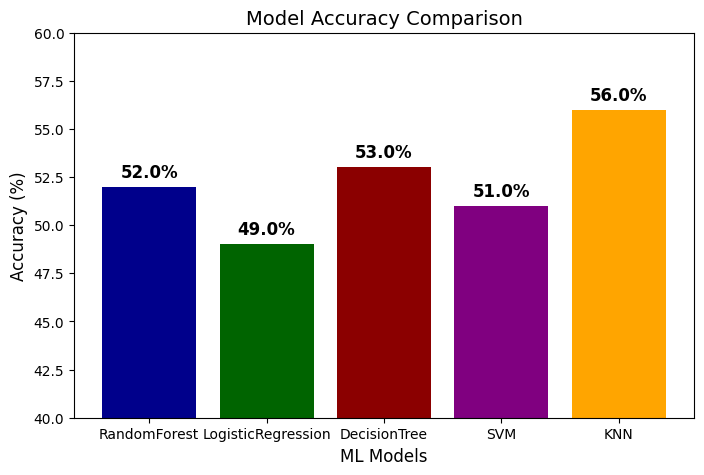

In [28]:
accuracy_results = {
    "RandomForest": 52.00,
    "LogisticRegression": 49.00,
    "DecisionTree": 53.00,
    "SVM": 51.00,
    "KNN": 56.00
}

# Colors for better visualization
colors = ['darkblue', 'darkgreen', 'darkred', 'purple', 'orange']

# Bar Chart
plt.figure(figsize=(8, 5))
plt.bar(accuracy_results.keys(), accuracy_results.values(), color=colors)

# Labels & Title
plt.xlabel("ML Models", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("Model Accuracy Comparison", fontsize=14)
plt.ylim(40, 60)  # Adjust limits for better visualization

# Display accuracy values on top of bars
for i, (model, acc) in enumerate(accuracy_results.items()):
    plt.text(i, acc + 0.5, f"{acc}%", ha='center', fontsize=12, fontweight='bold')

# Show plot
plt.show()

## Thanks...pls upvote!!!!